<a href="https://colab.research.google.com/github/Ashishjoshi794/Employee-Attrition-Prediction/blob/main/Copy_of_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv"
df = pd.read_csv(path)

#Initial Data Exploration

In [ ]:
print(df.shape)

(1470, 17)


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
0,41,Yes,Travel_Rarely,Sales,1,2,2,2,Sales Executive,4,Single,5993,Yes,0,8,1,6
1,49,No,Travel_Frequently,Research & Development,8,1,3,2,Research Scientist,2,Married,5130,No,1,10,3,10
2,37,Yes,Travel_Rarely,Research & Development,2,2,4,1,Laboratory Technician,3,Single,2090,Yes,0,7,3,0
3,33,No,Travel_Frequently,Research & Development,3,4,4,1,Research Scientist,3,Married,2909,Yes,0,8,3,8
4,27,No,Travel_Rarely,Research & Development,2,1,1,1,Laboratory Technician,2,Married,3468,No,1,6,3,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   BusinessTravel           1470 non-null   object
 3   Department               1470 non-null   object
 4   DistanceFromHome         1470 non-null   int64 
 5   Education                1470 non-null   int64 
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobLevel                 1470 non-null   int64 
 8   JobRole                  1470 non-null   object
 9   JobSatisfaction          1470 non-null   int64 
 10  MaritalStatus            1470 non-null   object
 11  MonthlyIncome            1470 non-null   int64 
 12  OverTime                 1470 non-null   object
 13  StockOptionLevel         1470 non-null   int64 
 14  TotalWorkingYears        1470 non-null  

In [ ]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobSatisfaction,MonthlyIncome,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.063946,2.728571,6502.931293,0.793878,11.279592,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.106940,1.102846,4707.956783,0.852077,7.780782,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,0.000000,6.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,1.000000,10.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,4.000000,8379.000000,1.000000,15.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,5.000000,4.000000,19999.000000,3.000000,40.000000,4.000000,40.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
JobLevel,0
JobRole,0
JobSatisfaction,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Target Variable Check

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
df["Attrition"].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


#eda

In [ ]:
df.head(1)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,StockOptionLevel,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
0,41,Yes,Travel_Rarely,Sales,1,2,2,2,Sales Executive,4,Single,5993,Yes,0,8,1,6


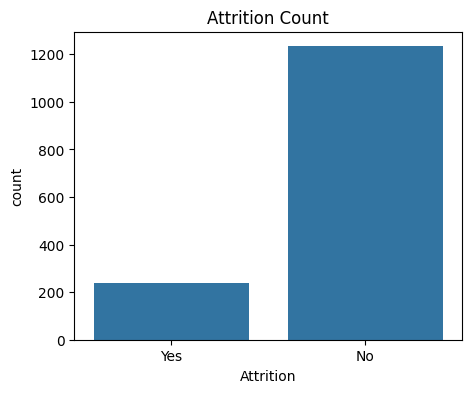

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="Attrition")
plt.title("Attrition Count")
plt.show()

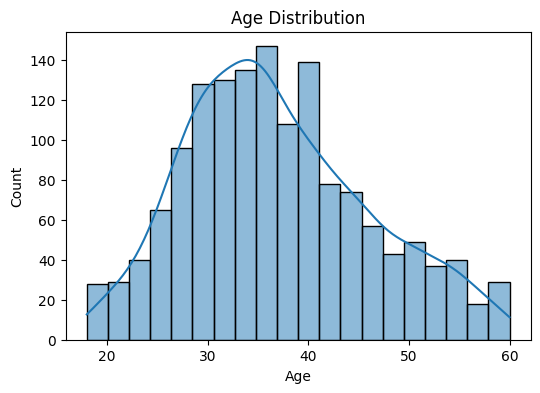

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

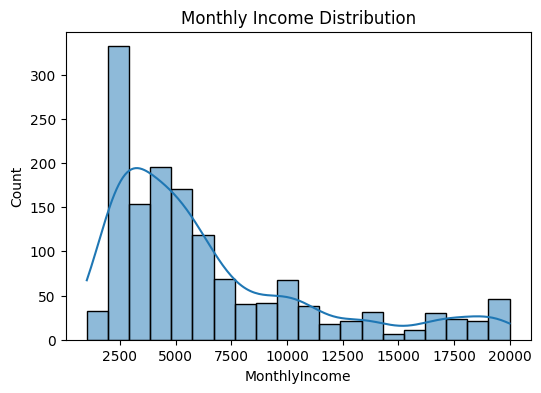

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyIncome"],bins=20,kde=True)
plt.title("Monthly Income Distribution")

plt.show()

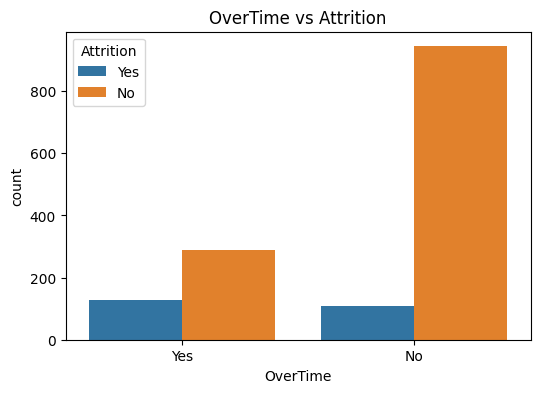

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="OverTime",hue="Attrition")
plt.title("OverTime vs Attrition")
plt.show()

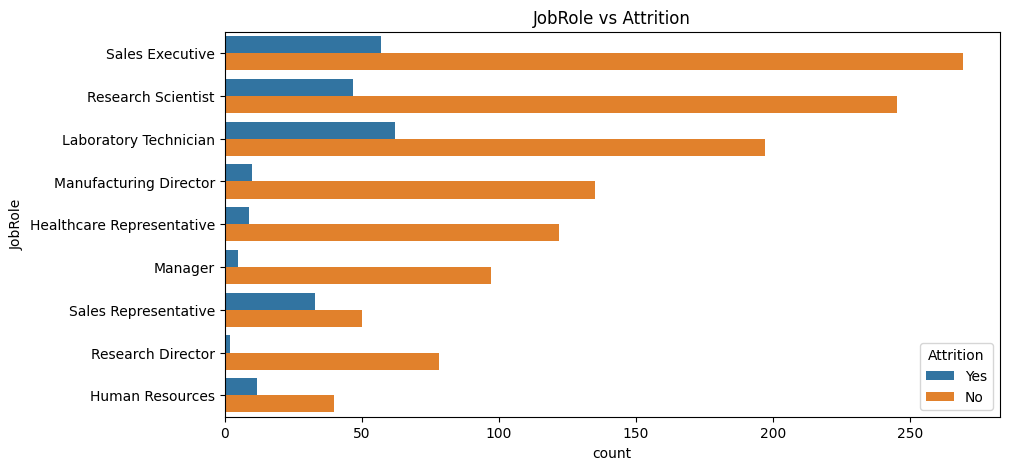

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,y="JobRole",hue="Attrition")
plt.title("JobRole vs Attrition")
plt.show()

Data Cleaning

In [ ]:
df=df.drop_duplicates()
print(df.shape)

(1470, 17)


In [ ]:
df.isnull().sum().sum()

np.int64(0)

#Encode Target

In [ ]:
df["Attrition"]=df["Attrition"].map({"Yes":1,"No":0})

In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


Feature Selection

In [ ]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]

In [ ]:
categorical=X.select_dtypes(include="object").columns
numerical=X.select_dtypes(exclude="object").columns

print(categorical)
print(numerical)

Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object')
Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')


Preprocessing Pipeline

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder

preprocessor=ColumnTransformer([
    ("num",StandardScaler(),numerical),
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical)
])

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 16)
(294, 16)


Train Multiple Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

Logistic Regression

In [ ]:
log_model=Pipeline([
    ("prep",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

log_model.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
tree_model=Pipeline([
    ("prep",preprocessor),
    ("model",DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
rf_model=Pipeline([
    ("prep",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus', 'OverTime'], dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

Evaluation Function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [ ]:
def evaluate(model,name):

    pred=model.predict(X_test)

    print("="*40)
    print(name)

    print("Accuracy :",accuracy_score(y_test,pred))
    print("Precision:",precision_score(y_test,pred))
    print("Recall   :",recall_score(y_test,pred))
    print("F1 Score :",f1_score(y_test,pred))

    print("\nClassification Report\n")
    print(classification_report(y_test,pred))

In [ ]:
evaluate(log_model,"Logistic Regression")
evaluate(tree_model,"Decision Tree")
evaluate(rf_model,"Random Forest")

Logistic Regression
Accuracy : 0.8639455782312925
Precision: 0.7058823529411765
Recall   : 0.2553191489361702
F1 Score : 0.375

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294

Decision Tree
Accuracy : 0.7619047619047619
Precision: 0.2909090909090909
Recall   : 0.3404255319148936
F1 Score : 0.3137254901960784

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.84      0.86       247
           1       0.29      0.34      0.31        47

    accuracy                           0.76       294
   macro avg       0.58      0.59      0.58       294
weighted avg       0.78      0.76      0.77       294

Random Forest
Accuracy : 0.8435374149

Confusion Matrix

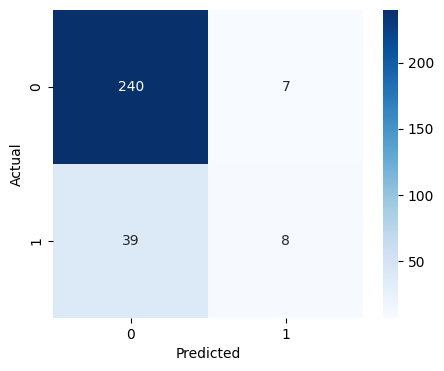

In [ ]:
pred=rf_model.predict(X_test)

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Cross Validation

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

from sklearn.model_selection import cross_val_score

scores=cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.42424242 0.48       0.3125     0.44444444 0.34375   ]
0.4009873737373738


In [ ]:
param_grid={
    "model__n_estimators":[100,200],
    "model__max_depth":[10,20,None],
    "model__min_samples_split":[2,5]
}

grid=GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [ ]:
best_model=grid.best_estimator_

In [ ]:
evaluate(best_model,"Best Random Forest")

Best Random Forest
Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [ ]:
prep=best_model.named_steps["prep"]

feature_names=prep.get_feature_names_out()

importances=best_model.named_steps["model"].feature_importances_

feat=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
})

feat=feat.sort_values("Importance",ascending=False)

feat.head(15)

,Feature,Importance
6,num__MonthlyIncome,0.124614
0,num__Age,0.106680
8,num__TotalWorkingYears,0.094643
1,num__DistanceFromHome,0.082822
10,num__YearsAtCompany,0.080456
3,num__EnvironmentSatisfaction,0.051828
9,num__WorkLifeBalance,0.049590
5,num__JobSatisfaction,0.045214
2,num__Education,0.040660
7,num__StockOptionLevel,0.038133


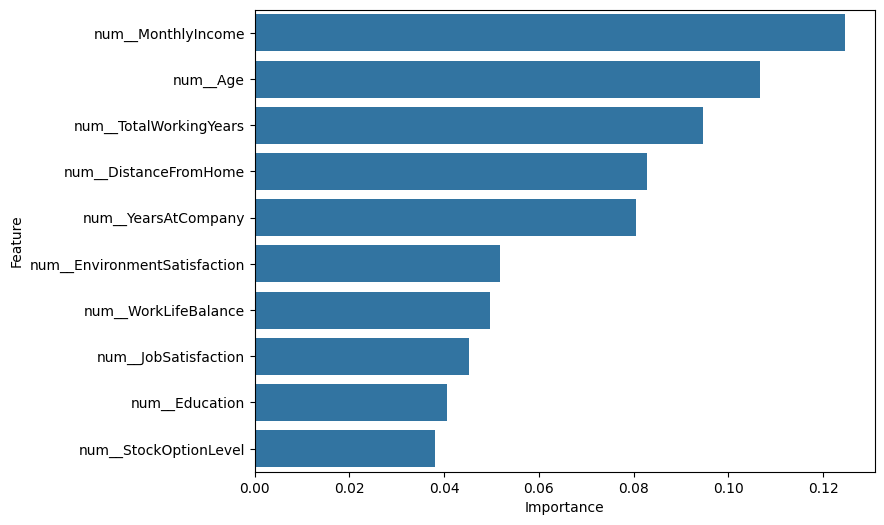

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feat.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

In [ ]:
sample=X_test.iloc[[0]]

prediction=best_model.predict(sample)[0]
probability=best_model.predict_proba(sample)[0][1]

print("Prediction:",prediction)
print("Attrition Probability:",round(probability*100,2),"%")

Prediction: 1
Attrition Probability: 56.5 %
